# 🎛️ Notebook 1 — Temperature: The DJ Knob

> **The vibe:** Imagine you're a DJ. Turn the knob left → everyone dances to the *same* song (predictable). Turn it right → total shuffle mode (anything can happen).  
> **What you'll see:** 5 graphs, one concept, zero confusion.  
> **Time:** ~10 minutes

---

## 🎯 The One Thing to Understand

Temperature **divides** every logit before softmax:

```
scaled_logit = original_logit / Temperature
```

- **T < 1.0** → gaps between logits get BIGGER → winner wins even more  
- **T = 1.0** → no change (the baseline)  
- **T > 1.0** → gaps get SMALLER → tokens become more equal

**Temperature never changes who is ranked #1. Only by how much.**


In [22]:
# ── Emoji Setup: PIL-based text overlay (bypasses Matplotlib glyph limits) ────
# We render emoji AFTER figures are saved using Pillow, not during matplotlib rendering
import sys
sys.path.insert(0, '.')  # Make emoji_text module importable
from emoji_text import inject_emoji_titles

# Suppress matplotlib glyph warnings since we'll add emoji via PIL
import warnings
warnings.filterwarnings('ignore', message='.*Glyph.*missing.*')

print("✅ Emoji rendering setup: figures will be post-processed with PIL for emoji support")


✅ Emoji rendering setup: figures will be post-processed with PIL for emoji support


In [23]:
# ── Setup (run this first, always) ──────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'text.color': '#e6edf3',
    'axes.labelcolor': '#8b949e', 'xtick.color': '#8b949e',
    'ytick.color': '#8b949e', 'grid.color': '#21262d',
    'axes.grid': True, 'grid.linewidth': 0.5, 'font.family': 'monospace'
})

# Our "model" — a decision system choosing a next action
TOKENS = ['approve', 'reject', 'review', 'escalate', 'delay',
          'audit', 'optimize', 'notify', 'assign', 'close']
LOGITS = np.array([2.2, 1.8, 1.4, 0.9, 0.2, 0.1, -0.3, -0.6, -0.8, -1.0])

def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

def apply_temp(logits, T):
    return softmax(logits / T)

print("✅ Setup done! Your model has 10 possible actions.")
print("Original logits:", dict(zip(TOKENS, LOGITS)))


✅ Setup done! Your model has 10 possible actions.
Original logits: {'approve': np.float64(2.2), 'reject': np.float64(1.8), 'review': np.float64(1.4), 'escalate': np.float64(0.9), 'delay': np.float64(0.2), 'audit': np.float64(0.1), 'optimize': np.float64(-0.3), 'notify': np.float64(-0.6), 'assign': np.float64(-0.8), 'close': np.float64(-1.0)}


## 🎬 Graph 1 — Watch the Distribution Transform

Run the cell below. You'll see the same 10 tokens at 5 different temperatures.

**What to look for:**
- 🔴 T=0.1 → one enormous bar, tiny everything else  
- 🟡 T=1.0 → baseline, natural shape  
- 🟢 T=5.0 → all bars nearly equal height

**Ask yourself:** At T=0.1, if you sampled 100 times, what would you get almost every time?


✅ Saved emoji-enhanced figure: graph1_temperature_faces.png


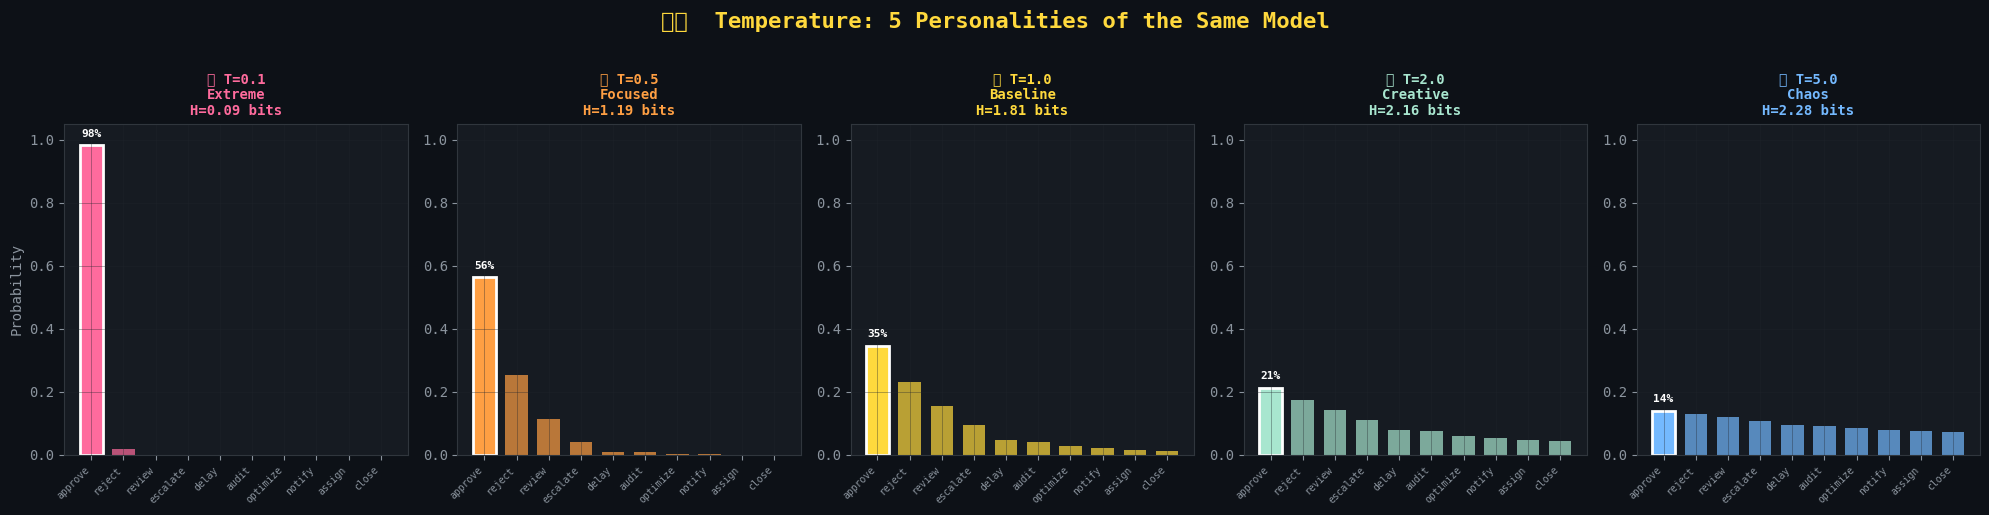


💡 Notice: 'approve' is ALWAYS the tallest bar — temperature never changes rank!
💡 But its probability goes from ~97% (T=0.1) to ~14% (T=5.0)


In [24]:
# ── Graph 1: The 5 Faces of Temperature ─────────────────────────────
temps   = [0.1, 0.5, 1.0, 2.0, 5.0]
colors  = ['#ff6b9d', '#ff9f43', '#ffd93d', '#a8e6cf', '#74b9ff']
labels  = ['🥶 T=0.1\nExtreme', '😐 T=0.5\nFocused',
           '😊 T=1.0\nBaseline', '😄 T=2.0\nCreative', '🤪 T=5.0\nChaos']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('🎛️  Temperature: 5 Personalities of the Same Model',
             fontsize=16, fontweight='bold', color='#ffd93d', y=1.02)

for ax, T, col, lbl in zip(axes, temps, colors, labels):
    probs = apply_temp(LOGITS, T)
    top   = np.argmax(probs)
    bars  = ax.bar(range(10), probs, color=col, alpha=0.7, width=0.7)
    bars[top].set_alpha(1.0)
    bars[top].set_edgecolor('white')
    bars[top].set_linewidth(2)
    entropy = -np.sum(probs * np.log(probs + 1e-12))
    ax.set_title(f'{lbl}\nH={entropy:.2f} bits', color=col, fontsize=10, fontweight='bold')
    ax.set_xticks(range(10))
    ax.set_xticklabels(TOKENS, rotation=45, ha='right', fontsize=7)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Probability' if ax == axes[0] else '')
    ax.text(top, probs[top] + 0.02, f'{probs[top]:.0%}',
            ha='center', va='bottom', color='white', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('graph1_temperature_faces.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
# Post-process: add emoji title via PIL to avoid matplotlib glyph warnings
inject_emoji_titles('graph1_temperature_faces.png', '🎛️  Temperature: 5 Personalities of the Same Model', title_y=15)
plt.show()
print("\n💡 Notice: 'approve' is ALWAYS the tallest bar — temperature never changes rank!")
print("💡 But its probability goes from ~97% (T=0.1) to ~14% (T=5.0)")


## 🎬 Graph 2 — The Dial Curve

The curve below shows something crucial: **temperature changes are not linear**.

Going from T=0.1→0.3 makes a HUGE difference.  
Going from T=3.0→5.0 makes almost no difference.

**The practical sweet spot is T=0.3 to T=1.2.** Outside that range, you're in diminishing-returns territory.


✅ Saved emoji-enhanced figure: graph2_temperature_dial.png


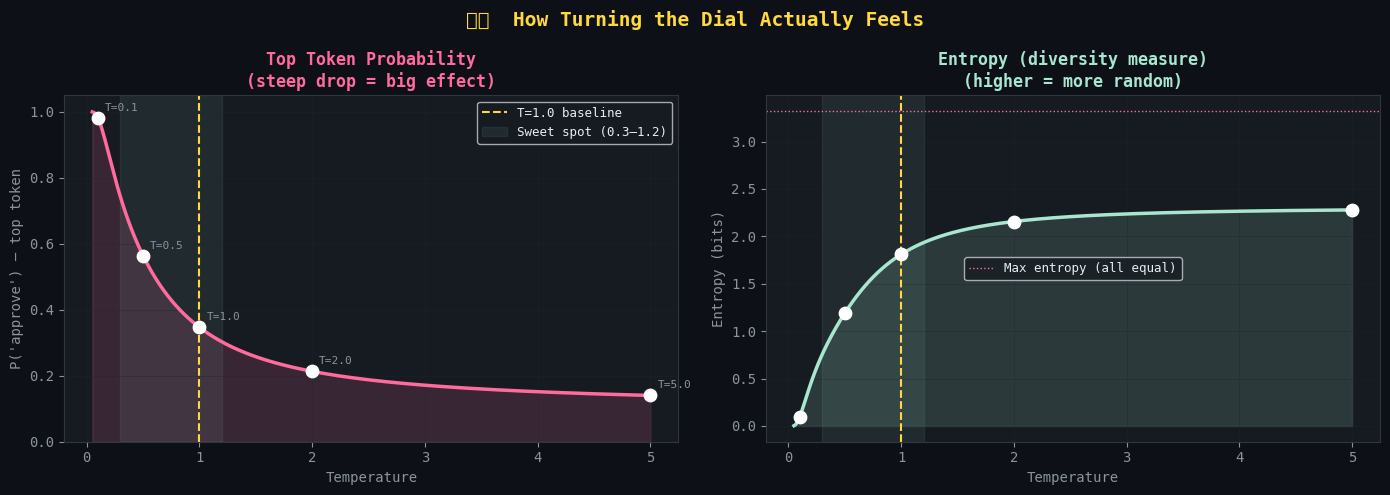


💡 Key insight: The curve is steep at low T and flat at high T.
💡 That means: small changes near T=0.1 have MASSIVE effects!
💡 Large changes near T=4.0 have almost NO effect.


In [25]:
# ── Graph 2: The Dial Curve ──────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🎛️  How Turning the Dial Actually Feels',
             fontsize=14, fontweight='bold', color='#ffd93d')

T_range = np.linspace(0.05, 5.0, 400)
top_probs = [apply_temp(LOGITS, T)[0] for T in T_range]  # approve is index 0
entropies = [-np.sum(apply_temp(LOGITS, T) * np.log(apply_temp(LOGITS, T) + 1e-12))
             for T in T_range]

# Panel 1: Top token probability
ax1.plot(T_range, top_probs, color='#ff6b9d', lw=2.5)
ax1.fill_between(T_range, top_probs, alpha=0.15, color='#ff6b9d')
ax1.axvline(1.0, color='#ffd93d', lw=1.5, ls='--', label='T=1.0 baseline')
# Mark the sweet spot
ax1.axvspan(0.3, 1.2, alpha=0.08, color='#a8e6cf', label='Sweet spot (0.3–1.2)')
for T in [0.1, 0.5, 1.0, 2.0, 5.0]:
    p = apply_temp(LOGITS, T)[0]
    ax1.scatter(T, p, s=80, color='white', zorder=5)
    ax1.annotate(f'T={T}', (T, p), textcoords='offset points',
                 xytext=(5, 5), color='#8b949e', fontsize=8)
ax1.set_xlabel('Temperature'); ax1.set_ylabel("P('approve') — top token")
ax1.set_title("Top Token Probability\n(steep drop = big effect)", color='#ff6b9d', fontweight='bold')
ax1.legend(fontsize=9); ax1.set_ylim(0, 1.05)

# Panel 2: Entropy
ax2.plot(T_range, entropies, color='#a8e6cf', lw=2.5)
ax2.fill_between(T_range, entropies, alpha=0.15, color='#a8e6cf')
ax2.axvline(1.0, color='#ffd93d', lw=1.5, ls='--')
ax2.axhline(np.log2(10), color='#ff6b9d', lw=1, ls=':', label='Max entropy (all equal)')
ax2.axvspan(0.3, 1.2, alpha=0.08, color='#a8e6cf')
for T in [0.1, 0.5, 1.0, 2.0, 5.0]:
    e = -np.sum(apply_temp(LOGITS, T) * np.log(apply_temp(LOGITS, T) + 1e-12))
    ax2.scatter(T, e, s=80, color='white', zorder=5)
ax2.set_xlabel('Temperature'); ax2.set_ylabel('Entropy (bits)')
ax2.set_title('Entropy (diversity measure)\n(higher = more random)', color='#a8e6cf', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('graph2_temperature_dial.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
inject_emoji_titles('graph2_temperature_dial.png', '🎛️  How Turning the Dial Actually Feels', title_y=15)
plt.show()
print("\n💡 Key insight: The curve is steep at low T and flat at high T.")
print("💡 That means: small changes near T=0.1 have MASSIVE effects!")
print("💡 Large changes near T=4.0 have almost NO effect.")


## 🎬 Graph 3 — The Full Heatmap (The "Big Picture" View)

This one graph shows *everything* at once — all temperatures, all tokens, simultaneously.

**How to read it:**
- **Bright yellow** = high probability at that (token, temperature) pair  
- **Dark purple** = near-zero probability  
- Watch the **left edge** (low T): one bright stripe, everything dark  
- Watch the **right edge** (high T): all stripes roughly equal brightness


✅ Saved emoji-enhanced figure: graph3_temperature_heatmap.png


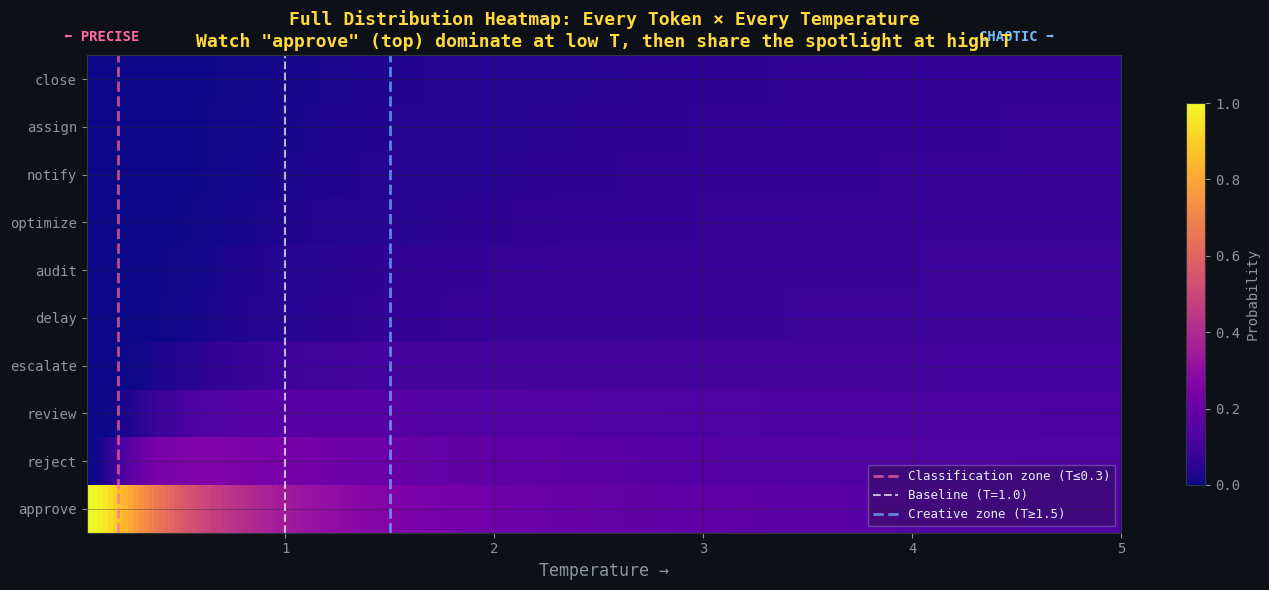


💡 This is the 'satellite view' of temperature.
💡 The bright horizontal band for 'approve' thins as T increases.
💡 By T=4.0, all bands are roughly the same brightness — that's near-random sampling.


In [26]:
# ── Graph 3: The Full Heatmap ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')

T_steps   = np.linspace(0.05, 5.0, 200)
heat_data = np.array([apply_temp(LOGITS, T) for T in T_steps]).T  # shape: (10, 200)

im = ax.imshow(heat_data, aspect='auto', cmap='plasma',
               extent=[0.05, 5.0, -0.5, 9.5], origin='lower', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Probability', shrink=0.8)

ax.set_yticks(range(10))
ax.set_yticklabels(TOKENS, fontsize=10)
ax.set_xlabel('Temperature →', fontsize=12)
ax.set_title('Full Distribution Heatmap: Every Token × Every Temperature\n'
             'Watch "approve" (top) dominate at low T, then share the spotlight at high T',
             fontsize=13, fontweight='bold', color='#ffd93d')

# Annotations
ax.axvline(0.2, color='#ff6b9d', lw=2, ls='--', alpha=0.7, label='Classification zone (T≤0.3)')
ax.axvline(1.0, color='white', lw=1.5, ls='--', alpha=0.7, label='Baseline (T=1.0)')
ax.axvline(1.5, color='#74b9ff', lw=2, ls='--', alpha=0.7, label='Creative zone (T≥1.5)')
ax.legend(loc='lower right', fontsize=9, framealpha=0.3)

# Zone labels
ax.text(0.12, 9.8, '⬅ PRECISE', color='#ff6b9d', fontsize=10, fontweight='bold', ha='center')
ax.text(4.5, 9.8, 'CHAOTIC ➡', color='#74b9ff', fontsize=10, fontweight='bold', ha='center')

plt.tight_layout()
plt.savefig('graph3_temperature_heatmap.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
inject_emoji_titles('graph3_temperature_heatmap.png', '🌡️  Full Distribution Heatmap: Every Token × Every Temperature', title_y=15)
plt.show()
print("\n💡 This is the 'satellite view' of temperature.")
print("💡 The bright horizontal band for 'approve' thins as T increases.")
print("💡 By T=4.0, all bands are roughly the same brightness — that's near-random sampling.")


## 🎬 Graph 4 — Build Intuition by Sampling

Now let's actually *simulate sampling* — generate 200 tokens at different temperatures and count what we get.

**What to look for:**
- At T=0.1: the bar chart looks like a single spike  
- At T=2.0: bars are more spread  
- At T=5.0: all bars roughly equal

This is the **real-world consequence** of the math above.


✅ Saved emoji-enhanced figure: graph4_temperature_sampling.png


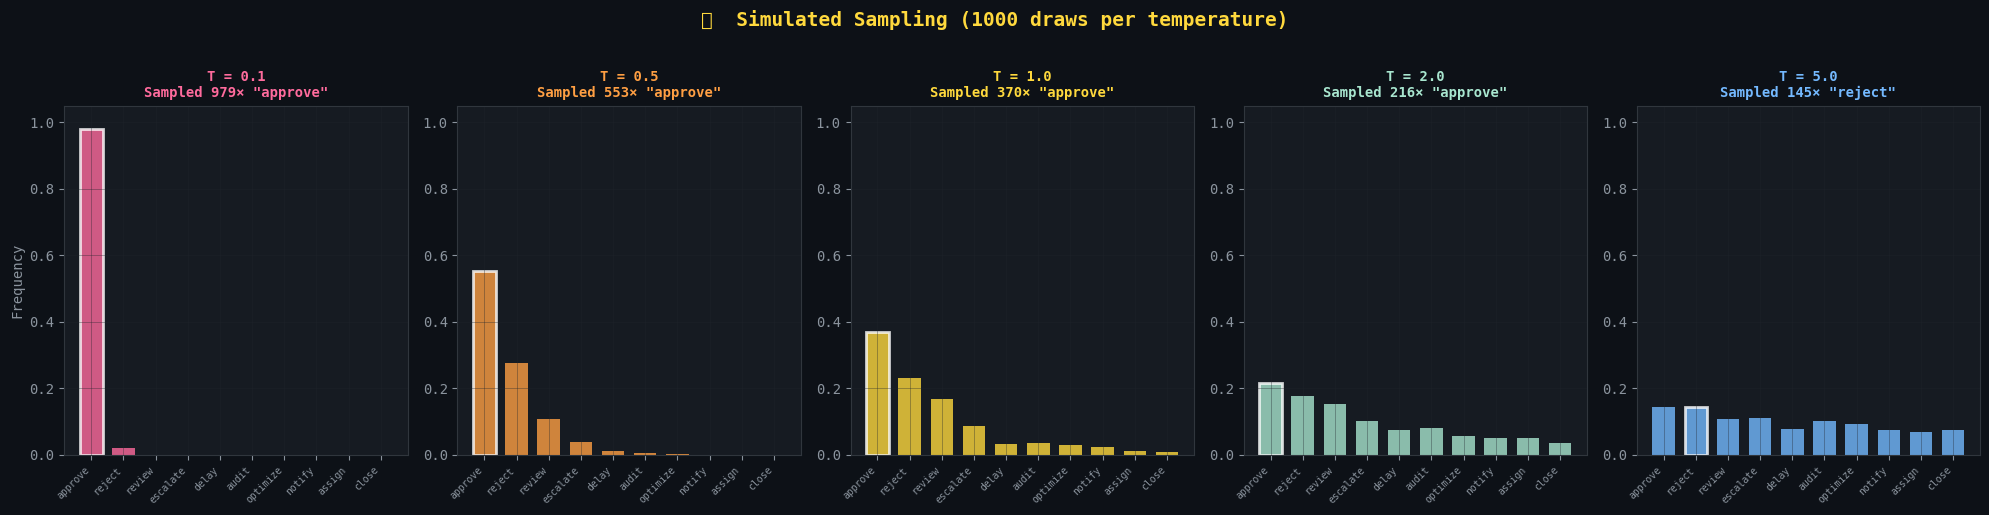


💡 At T=0.1: 'approve' appears ~981 out of 1000 times
💡 At T=5.0: 'approve' appears ~140 out of 1000 times
💡 Same model, same prompt — VERY different behavior just from changing T!


In [27]:
# ── Graph 4: Sampling Simulation ────────────────────────────────────
rng = np.random.default_rng(42)
temps_sim = [0.1, 0.5, 1.0, 2.0, 5.0]
colors_sim = ['#ff6b9d', '#ff9f43', '#ffd93d', '#a8e6cf', '#74b9ff']
N = 1000  # samples per temperature

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle(f'🎰  Simulated Sampling ({N} draws per temperature)',
             fontsize=14, fontweight='bold', color='#ffd93d', y=1.02)

for ax, T, col in zip(axes, temps_sim, colors_sim):
    probs  = apply_temp(LOGITS, T)
    counts = rng.multinomial(N, probs)
    freqs  = counts / N
    bars   = ax.bar(range(10), freqs, color=col, alpha=0.8, width=0.7)
    top    = np.argmax(freqs)
    bars[top].set_edgecolor('white'); bars[top].set_linewidth(2)
    ax.set_xticks(range(10))
    ax.set_xticklabels(TOKENS, rotation=45, ha='right', fontsize=7)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'T = {T}\nSampled {counts[top]}× "{TOKENS[top]}"',
                 color=col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Frequency' if ax == axes[0] else '')

plt.tight_layout()
plt.savefig('graph4_temperature_sampling.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
inject_emoji_titles('graph4_temperature_sampling.png', f'🎰  Simulated Sampling ({N} draws per temperature)', title_y=15)
plt.show()
print(f"\n💡 At T=0.1: 'approve' appears ~{int(apply_temp(LOGITS, 0.1)[0]*1000)} out of {N} times")
print(f"💡 At T=5.0: 'approve' appears ~{int(apply_temp(LOGITS, 5.0)[0]*1000)} out of {N} times")
print("💡 Same model, same prompt — VERY different behavior just from changing T!")


## 🎬 Graph 5 — Your Personal Temperature Playground

**Change the slider value (TEMP) and re-run to see the effect!**

Try:
- `TEMP = 0.01` → pure greedy (always approve)  
- `TEMP = 0.7` → production sweet spot  
- `TEMP = 3.0` → creative chaos

This is your personal tuning sandbox.


In [ ]:
# ── Graph 5: Your Playground ─────────────────────────────────────────
# 🎮 CHANGE THIS VALUE AND RE-RUN!
TEMP = 0.7  # ← Try: 0.01, 0.3, 0.7, 1.0, 1.5, 3.0

# ─────────────────────────────────────────────────────────────────────
probs   = apply_temp(LOGITS, TEMP)
entropy = -np.sum(probs * np.log(probs + 1e-12))
top_tok = TOKENS[np.argmax(probs)]
top_p   = probs.max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'🎮 Your Playground — Temperature = {TEMP}', fontsize=15,
             fontweight='bold', color='#ffd93d')

# Bar chart
colors_bar = ['#ff6b9d' if i == np.argmax(probs) else '#74b9ff' for i in range(10)]
ax1.bar(range(10), probs, color=colors_bar, alpha=0.85, width=0.7)
ax1.set_xticks(range(10)); ax1.set_xticklabels(TOKENS, rotation=45, ha='right')
ax1.set_ylabel('Probability'); ax1.set_ylim(0, 1.05)
ax1.set_title(f'Distribution at T={TEMP}\nTop token: "{top_tok}" ({top_p:.1%})',
              color='#ffd93d', fontweight='bold')

# Gauge showing where this T sits on the spectrum
T_range2  = np.linspace(0.05, 5.0, 400)
top_probs2= [apply_temp(LOGITS, T)[0] for T in T_range2]
ax2.plot(T_range2, top_probs2, color='#74b9ff', lw=2.5, alpha=0.6)
ax2.scatter([TEMP], [top_p], s=250, color='#ffd93d', zorder=10,
            edgecolors='white', linewidth=2, label=f'You are here (T={TEMP})')
ax2.axvline(TEMP, color='#ffd93d', lw=1.5, ls='--', alpha=0.7)
zones = [(0, 0.3, '#ff6b9d', 'Precise'), (0.3, 1.2, '#a8e6cf', 'Balanced'),
         (1.2, 2.5, '#ffd93d', 'Creative'), (2.5, 5.0, '#74b9ff', 'Chaotic')]
for x0, x1, col, lbl in zones:
    ax2.axvspan(x0, x1, alpha=0.07, color=col)
    ax2.text((x0+x1)/2, 0.97, lbl, ha='center', va='top', color=col, fontsize=9, fontweight='bold')
ax2.set_xlabel('Temperature'); ax2.set_ylabel("P(top token)")
ax2.set_title(f'Where T={TEMP} sits on the spectrum', color='#ffd93d', fontweight='bold')
ax2.legend(fontsize=10); ax2.set_ylim(0, 1.05)

print(f"📊 Stats for T={TEMP}:")
print(f"   Top token:  '{top_tok}' at {top_p:.1%}")
print(f"   Entropy:    {entropy:.3f} bits")
zone = 'Precise' if TEMP <= 0.3 else 'Balanced' if TEMP <= 1.2 else 'Creative' if TEMP <= 2.5 else 'Chaotic'
print(f"   Zone:       {zone}")
print(f"   Viable (>5%): {sum(probs > 0.05)} tokens")

plt.tight_layout()
plt.savefig('graph5_temperature_playground.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
inject_emoji_titles('graph5_temperature_playground.png', f'🎮 Your Playground — Temperature = {TEMP}', title_y=15)
plt.show()


## ✅ Notebook 1 Complete — What You Learned

| Concept | In One Line |
|---|---|
| Temperature | Divides all logits before softmax |
| T < 1.0 | Amplifies differences → confident, repetitive |
| T > 1.0 | Compresses differences → diverse, random |
| Entropy | One number measuring "how spread out" the distribution is |
| Sweet spot | T = 0.3–1.2 for most real tasks |

> **🎯 The DJ Knob metaphor holds:** Low T = same song every time. High T = shuffle. Most parties want something in between.

**Next notebook → `02_top_p.ipynb`: The Probability Budget 💰**
